# Homework 4

The homework is to prepare a report for the Ministry of Transport, revealing the nature and characteristics of flight delays. The report should help identify problem areas and contribute to decision-making. Therefore, strive not to state general facts, but to show problems. For example, the fact "the average departure delay is 15 minutes" by itself says little and does not help to understand why this is happening. On the contrary, a graph showing that on Mondays delays increase threefold compared to other days against the background of an increase in the number of flights and passengers suggests a possible cause of the problem: airports cannot cope with uneven load.

The report should be in the form of a notebook with a clear structure. At the beginning of the Markdown cell there is a brief description of the question under study (what we will study), then the code and all its outputs (tables, graphs, values), then again in the Markdown cell in which your brief conclusion is formulated.

The report should contain at least **5 results** confirmed by graphs. For variety of material, use different types of diagrams. All graphs should be provided with the necessary signatures (axis designations, title, color scheme legend).

To solve the problems, use the methods of the `pandas` library.

## Загрузка библиотек и данных, первичный осмотр данных

In [1]:
#Подключение библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Загрузка данных из файлов
flights = pd.read_csv('flights.csv', low_memory=False)

#Зададим правила вывода
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.2f}'.format

In [3]:
#Функция для получения предварительной информации о данных
def data_info(data):
    #Получение предварительной информации о данных из датасета через метод info
    data.info()

    #Расчет доли пропущенных значений в каждом из столбцов датасета
    print()
    print('Доля пропущенных значений:')
    mis_values_visit = data.isnull().sum().to_frame('missing_values')
    mis_values_visit['Доля'] = round(data.isna().mean(),2)
    print(mis_values_visit.sort_values(by='Доля', ascending=False))
    print()

    #Получение предварительной информации о данных через отображение первых строк датасета
    display(data.head())

In [4]:
#Получение предварительной информации о данных flights
data_info(flights)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,"2,354.00",-11.00,21.00,15.00,205.00,194.00,169.00,1448,404.00,4.00,430,408.00,-22.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.00,-8.00,12.00,14.00,280.00,279.00,263.00,2330,737.00,4.00,750,741.00,-9.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.00,-2.00,16.00,34.00,286.00,293.00,266.00,2296,800.00,11.00,806,811.00,5.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.00,-5.00,15.00,30.00,285.00,281.00,258.00,2342,748.00,8.00,805,756.00,-9.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.00,-1.00,11.00,35.00,235.00,215.00,199.00,1448,254.00,5.00,320,259.00,-21.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN


### Промежуточный вывод по исходному состоянию данных
На текущем этапе работы с данными можно заметить следующее:
    
- В данных много пропусков, преимущественно в столбцах, связанных с задержками и отменами рейсов, что скорее всего связано с тем, что у большинства рейсов нет проблем, и поэтому значения в этих столбцах у них пропущены;


- Типы данных некоторых столбцов не соответствуют содержащися в них данным, требуется некоторые правки - это относится к столбцам 'CANCELLED' и 'DIVERTED', их стоит привести к типу 'bool';


- Стоит рассмотреть столбцы, в которых от одного до трёх пропусков, скорее всего в записях есть некотрые ошибки.

 ## Предобработка данных

### Обработка пропусков

Сначала рассмотрим столбцы, в котрых не более 3 пропусков:

In [5]:
#Вывод датасета с условием
display(flights[flights['FLIGHT_NUMBER'].isnull()])

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY


Есть запись о рейсе, о котором практически нет никакой информации кроме даты и кода авиакомпании. Эта запись бесполезна для исследования, поэтому ее можно спокойно удалить.

In [6]:
#Удаление строки, в которой не указан номер рейса
flights = flights.dropna(subset=['FLIGHT_NUMBER']).reset_index(drop=True)

Рассмотрим еще столбец 'SCHEDULED_TIME', где осталось два пропуска:



In [7]:
#Вывод строк с пропусками в столбце 'SCHEDULED_TIME'
display(flights[flights['SCHEDULED_TIME'].isnull()])

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
483174,2015,2,1,7,NK,416,N627NK,FLL,IAG,2215,"2,206.00",-9.00,21.00,"2,227.00",NaN,NaN,NaN,1176,NaN,NaN,107,NaN,NaN,0,1,B,NaN,NaN,NaN,NaN,NaN
619941,2015,2,10,2,NK,416,N632NK,FLL,IAG,2215,"2,206.00",-9.00,16.00,"2,222.00",NaN,NaN,NaN,1176,NaN,NaN,107,NaN,NaN,0,1,B,NaN,NaN,NaN,NaN,NaN
1720237,2015,4,20,1,NK,174,N630NK,FLL,LGA,1602,"1,857.00",175.00,24.00,"1,921.00",NaN,NaN,NaN,1076,NaN,NaN,1900,NaN,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN
1820960,2015,4,26,7,NK,720,N614NK,DEN,DFW,2059,"2,057.00",-2.00,13.00,"2,110.00",NaN,NaN,NaN,641,NaN,NaN,2350,NaN,NaN,0,1,B,NaN,NaN,NaN,NaN,NaN
2031482,2015,5,9,6,NK,324,N620NK,MCO,ACY,2130,"2,152.00",22.00,18.00,"2,210.00",NaN,NaN,NaN,852,NaN,NaN,2340,NaN,NaN,0,1,B,NaN,NaN,NaN,NaN,NaN
2034453,2015,5,10,7,NK,368,N534NK,ORD,BWI,825,"1,214.00",229.00,18.00,"1,232.00",NaN,NaN,NaN,622,NaN,NaN,1118,NaN,NaN,0,1,C,NaN,NaN,NaN,NaN,NaN


Эти записи о двух рейсах одного и того же самолёта одной авиакомпании с одним и тем же маршрутом с разницей в 9 дней, которые были отменены после начала полёта. Судя по всему была какая-то проблема, которая дважды не не дала саvолёту закончить рейс. Посмотрим его на другие рейсы:

In [8]:
#Вывод датасета с условием
display(flights[flights['TAIL_NUMBER'] ==  'N627NK'])

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
6323,2015,1,1,4,NK,724,N627NK,FLL,LBE,1313,"1,309.00",-4.00,18.00,"1,327.00",158.00,159.00,137.00,980,"1,544.00",4.00,1551,"1,548.00",-3.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
9485,2015,1,1,4,NK,727,N627NK,LBE,FLL,1631,"1,641.00",10.00,11.00,"1,652.00",175.00,155.00,135.00,980,"1,907.00",9.00,1926,"1,916.00",-10.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
13552,2015,1,1,4,NK,416,N627NK,FLL,IAG,2155,"2,151.00",-4.00,15.00,"2,206.00",174.00,182.00,161.00,1176,47.00,6.00,49,53.00,4.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
14025,2015,1,2,5,NK,647,N627NK,IAG,FLL,200,156.00,-4.00,9.00,205.00,184.00,180.00,162.00,1176,447.00,9.00,504,456.00,-8.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
14182,2015,1,2,5,NK,895,N627NK,FLL,SJU,545,603.00,18.00,20.00,623.00,150.00,150.00,124.00,1046,927.00,6.00,915,933.00,18.00,0,0,NaN,18.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5806457,2015,12,31,4,NK,815,N627NK,PHL,ORD,600,559.00,-1.00,12.00,611.00,140.00,138.00,114.00,678,705.00,12.00,720,717.00,-3.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5808509,2015,12,31,4,NK,815,N627NK,ORD,MSY,810,810.00,0.00,11.00,821.00,140.00,134.00,120.00,837,"1,021.00",3.00,1030,"1,024.00",-6.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5811244,2015,12,31,4,NK,810,N627NK,MSY,DTW,1113,"1,109.00",-4.00,9.00,"1,118.00",151.00,141.00,118.00,926,"1,416.00",14.00,1444,"1,430.00",-14.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5815120,2015,12,31,4,NK,683,N627NK,DTW,RSW,1534,"1,532.00",-2.00,14.00,"1,546.00",174.00,157.00,141.00,1084,"1,807.00",2.00,1828,"1,809.00",-19.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN


Видно, что подобная ситуация была единичной, до и после неё самолёт совершал рейсы без особых проблем, так что видимо здесь идёт речь или о каких-то неисправностях, или о тестовых полётах, или о каком-то внешнем факторе, повлиявшим на возможность закончить рейс.

С учётом всего можно отбросить эти две записи ради дальнейшего удобства работы с данными, так как они аномальны, а их количсество незначительно относительно общего количества данных:

In [9]:
#Удаление строк, в которых не указано время
flights = flights.dropna(subset=['SCHEDULED_TIME']).reset_index(drop=True)

Теперь рассмотрим записи, в которых отсутствуют идентификаторы самолётов:

In [10]:
display(flights[flights['TAIL_NUMBER'].isnull()])

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
297,2015,1,1,4,F9,865,NaN,MSO,DEN,600,NaN,NaN,NaN,NaN,120.00,NaN,NaN,679,NaN,NaN,800,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN
298,2015,1,1,4,F9,1256,NaN,ORD,MIA,600,NaN,NaN,NaN,NaN,180.00,NaN,NaN,1197,NaN,NaN,1000,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN
2216,2015,1,1,4,UA,641,NaN,LAX,HNL,845,NaN,NaN,NaN,NaN,344.00,NaN,NaN,2556,NaN,NaN,1229,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN
3490,2015,1,1,4,UA,1412,NaN,ORD,PHL,1010,NaN,NaN,NaN,NaN,121.00,NaN,NaN,678,NaN,NaN,1311,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN
3763,2015,1,1,4,US,1883,NaN,SLC,PHL,1030,NaN,NaN,NaN,NaN,243.00,NaN,NaN,1927,NaN,NaN,1633,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5811602,2015,12,31,4,UA,598,NaN,SMF,DEN,1134,NaN,NaN,NaN,NaN,148.00,NaN,NaN,909,NaN,NaN,1502,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN
5813412,2015,12,31,4,UA,338,NaN,PDX,SFO,1339,NaN,NaN,NaN,NaN,110.00,NaN,NaN,550,NaN,NaN,1529,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN
5813855,2015,12,31,4,UA,1828,NaN,SEA,IAH,1405,NaN,NaN,NaN,NaN,258.00,NaN,NaN,1874,NaN,NaN,2023,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN
5818084,2015,12,31,4,UA,1789,NaN,IAH,TPA,1955,NaN,NaN,NaN,NaN,125.00,NaN,NaN,787,NaN,NaN,2300,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN


In [11]:
#Вывод уникальных значений столбца 'CANCELLATION_REASON' для записей с пропуском в столбце 'TAIL_NUMBER'
flights[flights['TAIL_NUMBER'].isnull()]['CANCELLATION_REASON'].unique()

array(['A', 'B', 'C'], dtype=object)

Для всех этих рейсов было назначено время отправления, но после они были отменены. Эти данные не стоит удалять, так как их значительное количество, и они будут важны для дальнейшего анализа. Заполним пропуски в них значением 'no_tail' для удобства в дальнейшем:

In [12]:
#Заполнение пропусков в столбце 'TAIL_NUMBER' индикаторным значением
flights['TAIL_NUMBER'] = flights['TAIL_NUMBER'].fillna('no_tail')

In [13]:
display(flights[flights['TAIL_NUMBER'] == 'no_tail'])

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
297,2015,1,1,4,F9,865,no_tail,MSO,DEN,600,NaN,NaN,NaN,NaN,120.00,NaN,NaN,679,NaN,NaN,800,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN
298,2015,1,1,4,F9,1256,no_tail,ORD,MIA,600,NaN,NaN,NaN,NaN,180.00,NaN,NaN,1197,NaN,NaN,1000,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN
2216,2015,1,1,4,UA,641,no_tail,LAX,HNL,845,NaN,NaN,NaN,NaN,344.00,NaN,NaN,2556,NaN,NaN,1229,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN
3490,2015,1,1,4,UA,1412,no_tail,ORD,PHL,1010,NaN,NaN,NaN,NaN,121.00,NaN,NaN,678,NaN,NaN,1311,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN
3763,2015,1,1,4,US,1883,no_tail,SLC,PHL,1030,NaN,NaN,NaN,NaN,243.00,NaN,NaN,1927,NaN,NaN,1633,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5811602,2015,12,31,4,UA,598,no_tail,SMF,DEN,1134,NaN,NaN,NaN,NaN,148.00,NaN,NaN,909,NaN,NaN,1502,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN
5813412,2015,12,31,4,UA,338,no_tail,PDX,SFO,1339,NaN,NaN,NaN,NaN,110.00,NaN,NaN,550,NaN,NaN,1529,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN
5813855,2015,12,31,4,UA,1828,no_tail,SEA,IAH,1405,NaN,NaN,NaN,NaN,258.00,NaN,NaN,1874,NaN,NaN,2023,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN
5818084,2015,12,31,4,UA,1789,no_tail,IAH,TPA,1955,NaN,NaN,NaN,NaN,125.00,NaN,NaN,787,NaN,NaN,2300,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN


Теперь рассмотрим столбец 'CANCELLATION_REASON':

In [14]:
#Вывод уникальных значений столбца 'CANCELLATION_REASON' для записей со значением 0 в столбце 'CANCELLED'
print(flights[flights['CANCELLED'] == 0]['CANCELLATION_REASON'].unique())

[nan]


В столбце 'CANCELLATION_REASON' пропуски означают, что рейс не был отменен, заполним их значением:

In [15]:
#Заполнение пропусков в столбце 'CANCELLATION_REASON' индикаторным значением
flights['CANCELLATION_REASON'] = flights['CANCELLATION_REASON'].fillna('not_cancelled')

Проверим, перекаются ли пропуски по столбцам 'LATE_AIRCRAFT_DELAY', 'AIRLINE_DELAY', 'AIR_SYSTEM_DELAY', 'WEATHER_DELAY' и 'SECURITY_DELAY':

In [16]:
#Расчет доли пропущенных значений в каждом из столбцов датасета, у которых есть пропуски в столбце 'LATE_AIRCRAFT_DELAY'
print('Доля пропущенных значений:')
mis_values_visit = flights[flights['LATE_AIRCRAFT_DELAY'].isnull()].isnull().sum().to_frame('missing_values')
mis_values_visit['Доля'] = round(flights[flights['LATE_AIRCRAFT_DELAY'].isnull()].isna().mean(),2)
print(mis_values_visit.sort_values(by='Доля', ascending=False))

Доля пропущенных значений:
                     missing_values  Доля
LATE_AIRCRAFT_DELAY         4755634  1.00
AIRLINE_DELAY               4755634  1.00
AIR_SYSTEM_DELAY            4755634  1.00
WEATHER_DELAY               4755634  1.00
SECURITY_DELAY              4755634  1.00
WHEELS_OFF                    89047  0.02
TAXI_OUT                      89047  0.02
AIR_TIME                     105065  0.02
WHEELS_ON                     92507  0.02
ELAPSED_TIME                 105065  0.02
DEPARTURE_TIME                86153  0.02
DEPARTURE_DELAY               86153  0.02
ARRIVAL_TIME                  92507  0.02
ARRIVAL_DELAY                105065  0.02
TAXI_IN                       92507  0.02
SCHEDULED_TIME                    0  0.00
ORIGIN_AIRPORT                    0  0.00
DESTINATION_AIRPORT               0  0.00
SCHEDULED_DEPARTURE               0  0.00
DAY_OF_WEEK                       0  0.00
AIRLINE                           0  0.00
FLIGHT_NUMBER                     0  0.00
TAIL_NU

Да, они совпали. Пропущенные значения в этих столбцах означают, что рейс не задерживался, т.е. либо был отменен, либо прошёл нормально. Пропуски в этих столбцах стоит оставить без изменений, так как их заполнение может повлиять на результаты исследования.
На текщий момент картина следующая:

In [17]:
#Расчет доли пропущенных значений в каждом из столбцов датасета
print('Доля пропущенных значений:')
mis_values_visit = flights.isnull().sum().to_frame('missing_values')
mis_values_visit['Доля'] = round(flights.isna().mean(),2)
print(mis_values_visit.sort_values(by='Доля', ascending=False))

Доля пропущенных значений:
                     missing_values  Доля
LATE_AIRCRAFT_DELAY         4755634  0.82
AIRLINE_DELAY               4755634  0.82
AIR_SYSTEM_DELAY            4755634  0.82
WEATHER_DELAY               4755634  0.82
SECURITY_DELAY              4755634  0.82
TAXI_OUT                      89047  0.02
WHEELS_OFF                    89047  0.02
AIR_TIME                     105065  0.02
WHEELS_ON                     92507  0.02
ELAPSED_TIME                 105065  0.02
TAXI_IN                       92507  0.02
ARRIVAL_DELAY                105065  0.02
ARRIVAL_TIME                  92507  0.02
DEPARTURE_DELAY               86153  0.01
DEPARTURE_TIME                86153  0.01
SCHEDULED_TIME                    0  0.00
ORIGIN_AIRPORT                    0  0.00
DESTINATION_AIRPORT               0  0.00
SCHEDULED_DEPARTURE               0  0.00
DAY_OF_WEEK                       0  0.00
AIRLINE                           0  0.00
FLIGHT_NUMBER                     0  0.00
TAIL_NU

Пропуски в оставшихся столбцах часто пересекаются по записям, а также в каждом из них идёт речь о том, в какие моменты времени произошли ключевые события рейс - время взлёта, время отбытия и так далее. Скорее всего это из-за отсутствия систем отслеживания этих моментов, которые могли бы собрать эти данные.

Пропуски в этих столбцах можно оставить незаполненными, но если во время исследования будут рассматриваться эти характеристики, то столбцы с пропусками можно будет отбросить в силу их не очень большого количества.

### Приведение стобцов к правильному типу данных

Приведем столбцы 'DIVERTED' и 'CANCELLED' к типу 'bool':

In [18]:
#Приведение столбцов к нужному типу
flights['DIVERTED'] = flights['DIVERTED'].astype(bool)
flights['CANCELLED'] = flights['CANCELLED'].astype(bool)

### Обработка дубликатов

Проверим записи на наличие дубликатов:

In [19]:
#Функция для подсчёта дубликатов
def data_duplicates_sum(data, name):
    if data.duplicated().sum() > 0:
        print(f'Количество дубликатов в таблице {name}: {data.duplicated().sum()}')
    else:
        print(f'В таблице {name} явных дубликатов нет')

In [20]:
#Проверка на наличие явных дубликатов в датафрейме
data_duplicates_sum(data=flights, name='flights')

В таблице flights явных дубликатов нет


###  Промежуточный вывод после предобработки
На текущем этапе работы с данными можно заметить следующее:

- Пропуски в датасете были обработаны - несколько записей были удалены из-за пропусков в ключевых для всего исследования столбцах, в столбцах 'TAIL_NUMBER' и 'CANCELLATION_REASON' они были заполнены индикаторными значениями, а в остальных были оставлены неизменными;


- В датафрейме не было явных дубликатов;


- Столбцы 'DIVERTED' и 'CANCELLED' были приведены к типу данных 'bool'.

 ## Исследование данных

### Анализ задержек по дням недели

Для начала проанализируем как связана средняя задержка в минутах с количеством рейсов по дням:

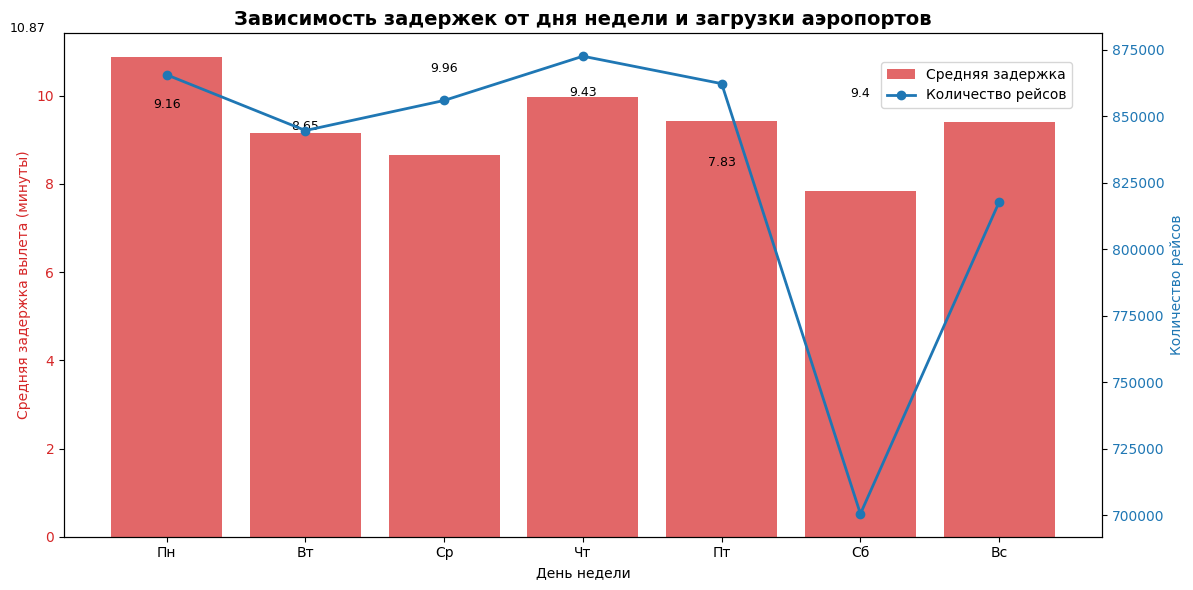

In [21]:
#Словарь для названий дней
days_map = {1: 'Пн', 2: 'Вт', 3: 'Ср', 4: 'Чт', 5: 'Пт', 6: 'Сб', 7: 'Вс'}

#Расчет средних задержек и количества рейсов по дням
daily_delays = flights.groupby('DAY_OF_WEEK')['DEPARTURE_DELAY'].mean().round(2)
daily_flights = flights.groupby('DAY_OF_WEEK').size()

#Создание фигуры с двумя осями
fig, ax1 = plt.subplots(figsize=(12, 6))

#График средних задержек (столбцы)
color = 'tab:red'
ax1.set_xlabel('День недели')
ax1.set_ylabel('Средняя задержка вылета (минуты)', color=color)
bars = ax1.bar(daily_delays.index, daily_delays.values, color=color, alpha=0.7, label='Средняя задержка')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(range(1, 8))
ax1.set_xticklabels([days_map[i] for i in range(1, 8)])

#Вторая ось для количества рейсов
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Количество рейсов', color=color)
line = ax2.plot(daily_flights.index, daily_flights.values, color=color, marker='o', linewidth=2, label='Количество рейсов')
ax2.tick_params(axis='y', labelcolor=color)

#Заголовок и легенда
plt.title('Зависимость задержек от дня недели и загрузки аэропортов', fontsize=14, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))

#Добавление значений на столбцы
for i, (idx, val) in enumerate(daily_delays.items()):
    ax1.text(i, val + 0.5, str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

#### Вывод 1
По графику видно, что пиковые задержки приходяться на дни с максимальным трафиком, и это указывает на неспособность инфраструктуры справляться с неравномерной нагрузкой.

### Анализ влияния дальности перелёта на задержки

Теперь посмотрим как влияет дальность перелёта на время задержки:

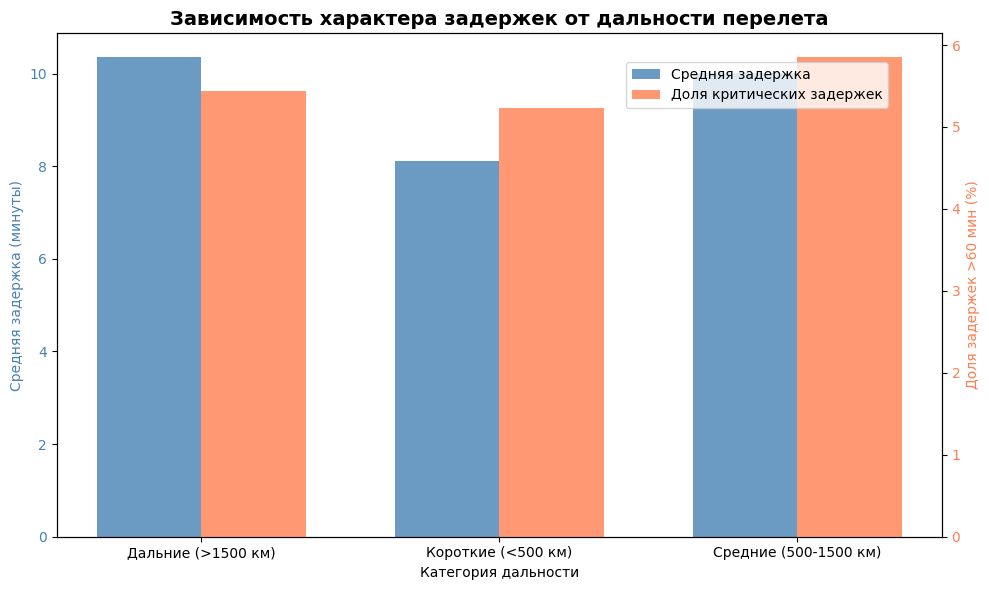

In [22]:
#Создание категорий дальности
def distance_category(dist):
    if dist < 500:
        return 'Короткие (<500 км)'
    elif dist < 1500:
        return 'Средние (500-1500 км)'
    else:
        return 'Дальние (>1500 км)'

#Создаем копию массива для построения графика
df2 = flights.copy()

df2['DISTANCE_CAT'] = df2['DISTANCE'].apply(distance_category)

#Расчет метрик для каждой категории
distance_stats = df2.groupby('DISTANCE_CAT').agg({
    'DEPARTURE_DELAY': ['mean', lambda x: (x > 60).mean() * 100]
}).round(2)
distance_stats.columns = ['Средняя задержка (мин)', 'Доля задержек >60 мин (%)']
distance_stats = distance_stats.reset_index()

#Создание групповой столбчатой диаграммы
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(distance_stats['DISTANCE_CAT']))
width = 0.35

bars1 = ax.bar(x - width/2, distance_stats['Средняя задержка (мин)'], width, label='Средняя задержка', color='steelblue', alpha=0.8)
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, distance_stats['Доля задержек >60 мин (%)'], width, label='Доля критических задержек', color='coral', alpha=0.8)

#Настройка графика
ax.set_xlabel('Категория дальности')
ax.set_ylabel('Средняя задержка (минуты)', color='steelblue')
ax2.set_ylabel('Доля задержек >60 мин (%)', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(distance_stats['DISTANCE_CAT'])
ax.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='coral')

plt.title('Зависимость характера задержек от дальности перелета', fontsize=14, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))

plt.tight_layout()
plt.show()

#### Вывод 2
По графику видно, что для дальних и средних рейсов характерна высокая доля критических задержек(т.е. задержек более чем на 60 минут), что скорее всего свидетельствует о проблеме 'эффекта домино' - накопления опозданий в течение операционного дня, а также о том, что для дальних рейсов труднее спрогнозировать их точные временные рамки. Сама средняя задержка во всех трёх случаях составляет меньше или около 10 минут, что является хорошим результатом.

### Сравнение утренних и вечерних рейсов

Проанализируем, как связано с задержкой время вылета - утром или вечером:

/tmp/ipykernel_2391/3621907172.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=time_filtered, x='TIME_CAT', y='DEPARTURE_DELAY', palette=['lightgreen', 'lightcoral'])


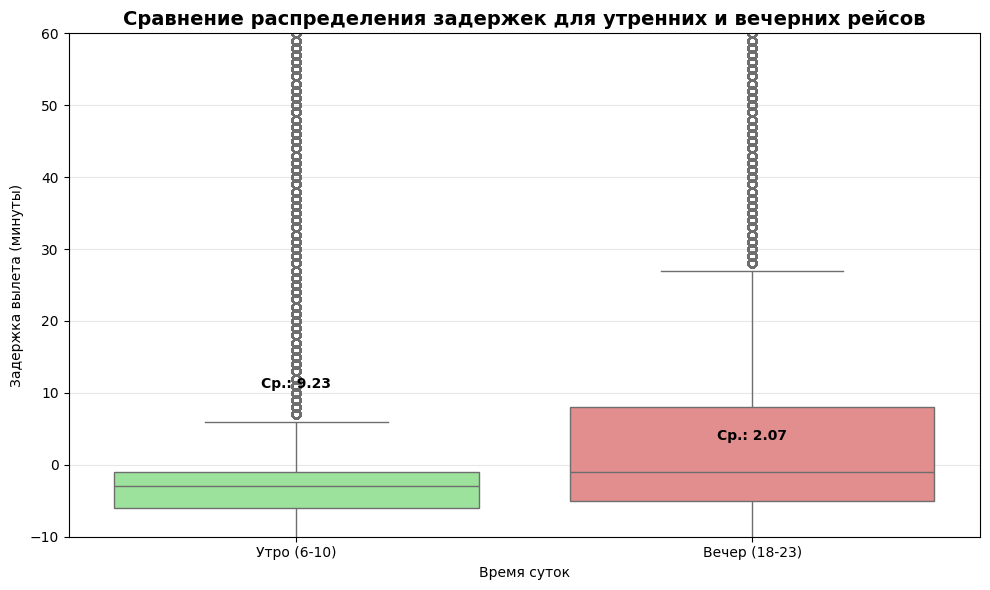

In [23]:
#Создание категории времени суток
def time_of_day(hour):
    if 6 <= hour <= 10:
        return 'Утро (6-10)'
    elif 18 <= hour <= 23:
        return 'Вечер (18-23)'
    else:
        return 'Другое'

#Создаем копию массива для построения графика
df2 = flights.copy()

#Предполагаем, что час извлечен из SCHEDULED_DEPARTURE
df2['HOUR'] = df2['SCHEDULED_DEPARTURE'] // 60
df2['TIME_CAT'] = df2['HOUR'].apply(time_of_day)

#Фильтрация только для утра и вечера
time_filtered = df2[df2['TIME_CAT'].isin(['Утро (6-10)', 'Вечер (18-23)'])]

#Удаление пропусков в задержках
time_filtered = time_filtered.dropna(subset=['DEPARTURE_DELAY'])

#Построение боксплота
plt.figure(figsize=(10, 6))
sns.boxplot(data=time_filtered, x='TIME_CAT', y='DEPARTURE_DELAY', palette=['lightgreen', 'lightcoral'])

#Ограничение оси Y для лучшей визуализации (убираем экстремальные выбросы)
plt.ylim(-10, 60)

plt.xlabel('Время суток')
plt.ylabel('Задержка вылета (минуты)')
plt.title('Сравнение распределения задержек для утренних и вечерних рейсов', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

#Добавление средних значений
means = time_filtered.groupby('TIME_CAT')['DEPARTURE_DELAY'].mean().round(2)
for i, (cat, mean_val) in enumerate(means.items()):
    plt.text(i, mean_val + 1, f'Ср.: {mean_val}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

#### Вывод 3
Видно, что для обеих категорий рейсов свойствены выбросы, но в целом вечерние рейсы имеют больший разброс задержек и более высокие средние значения, чем утренние. Ещё видно, что утренние рейсы часто начинаются раньше запланированного, в то время как у другой категории рейсов подобное встречается значительно реже. Также как и в предыдущем пункте, всё это говорит о том, что задержки имеют свойство накапливаться в течение операционного дня.

### Анализ проблемных маршрутов

Рассмотрим, каким маршрутам наиболее свойствены задержки:

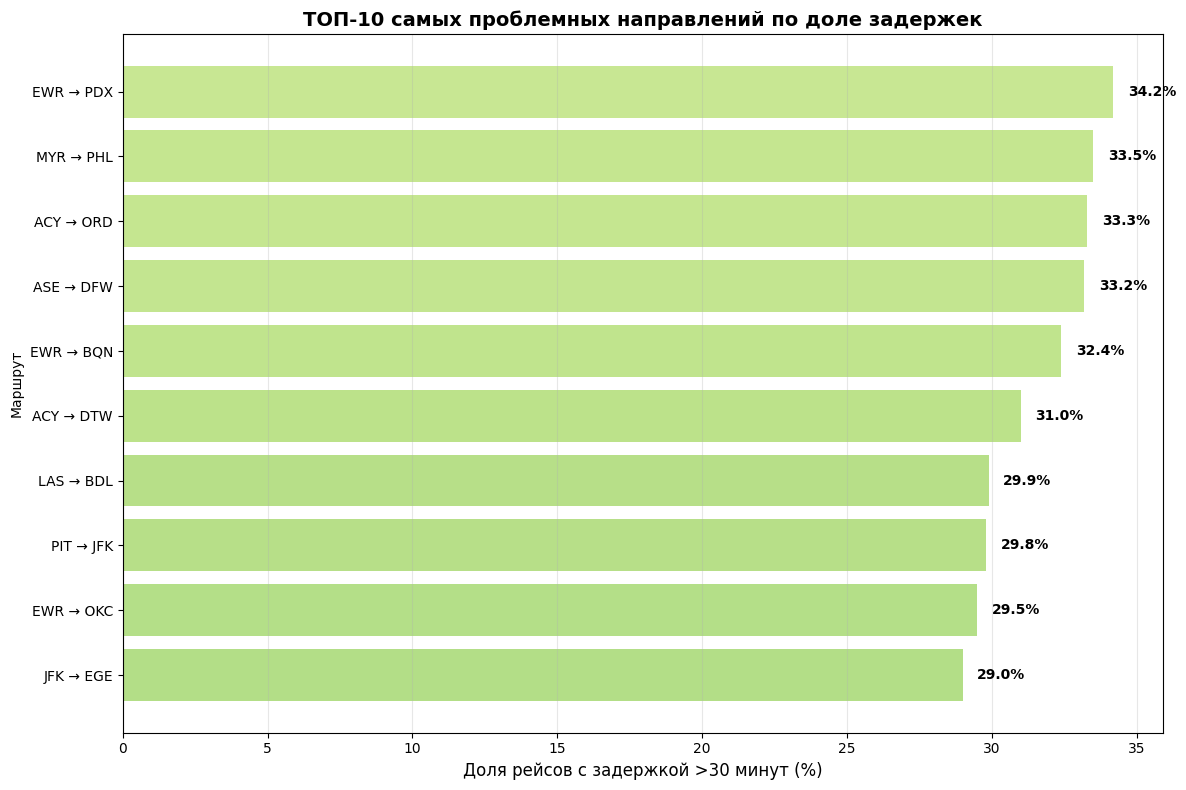

In [24]:
#Создаем копию массива для построения графика
df2 = flights.copy()

#Создание колонки с направлением
df2['ROUTE'] = df2['ORIGIN_AIRPORT'] + ' → ' + df2['DESTINATION_AIRPORT']

#Расчет доли задержанных рейсов (>30 минут) для каждого направления
route_delays = df2.groupby('ROUTE').agg(
    total_flights=('DEPARTURE_DELAY', 'count'),
    delayed_flights=('DEPARTURE_DELAY', lambda x: (x > 30).sum())
)
route_delays['delay_percent'] = (route_delays['delayed_flights'] / route_delays['total_flights'] * 100).round(1)

#Фильтрация направлений с достаточным количеством рейсов (минимум 100 за год)
significant_routes = route_delays[route_delays['total_flights'] >= 100]

#Выбор топ-10 худших по доле задержек
top_problematic = significant_routes.nlargest(10, 'delay_percent').sort_values('delay_percent')

#Построение горизонтальной столбчатой диаграммы
plt.figure(figsize=(12, 8))
colors = plt.cm.RdYlGn_r(top_problematic['delay_percent'] / 100)

bars = plt.barh(top_problematic.index, top_problematic['delay_percent'], color=colors, alpha=0.8)

plt.xlabel('Доля рейсов с задержкой >30 минут (%)', fontsize=12)
plt.ylabel('Маршрут')
plt.title('ТОП-10 самых проблемных направлений по доле задержек', fontsize=14, fontweight='bold')

#Добавление значений на график
for i, (idx, row) in enumerate(top_problematic.iterrows()):
    plt.text(row['delay_percent'] + 0.5, i, f"{row['delay_percent']}%", va='center', fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

#### Вывод 4
По графику видно, что на некоторых направлениях до трети рейсов задерживаются более чем на 30 минут. Стоит отдельно отметить аэропорты с идентификаторами EWR и JFK как самые часто встречающиеся в данном топ-10. Нельзя сказать с чем это связано, стоит проанализировать каждый конкретный маршрут отдельно.

### Анализ ежемесячной динамики

Теперь посмотрим как связаны месяц и средняя задержка:

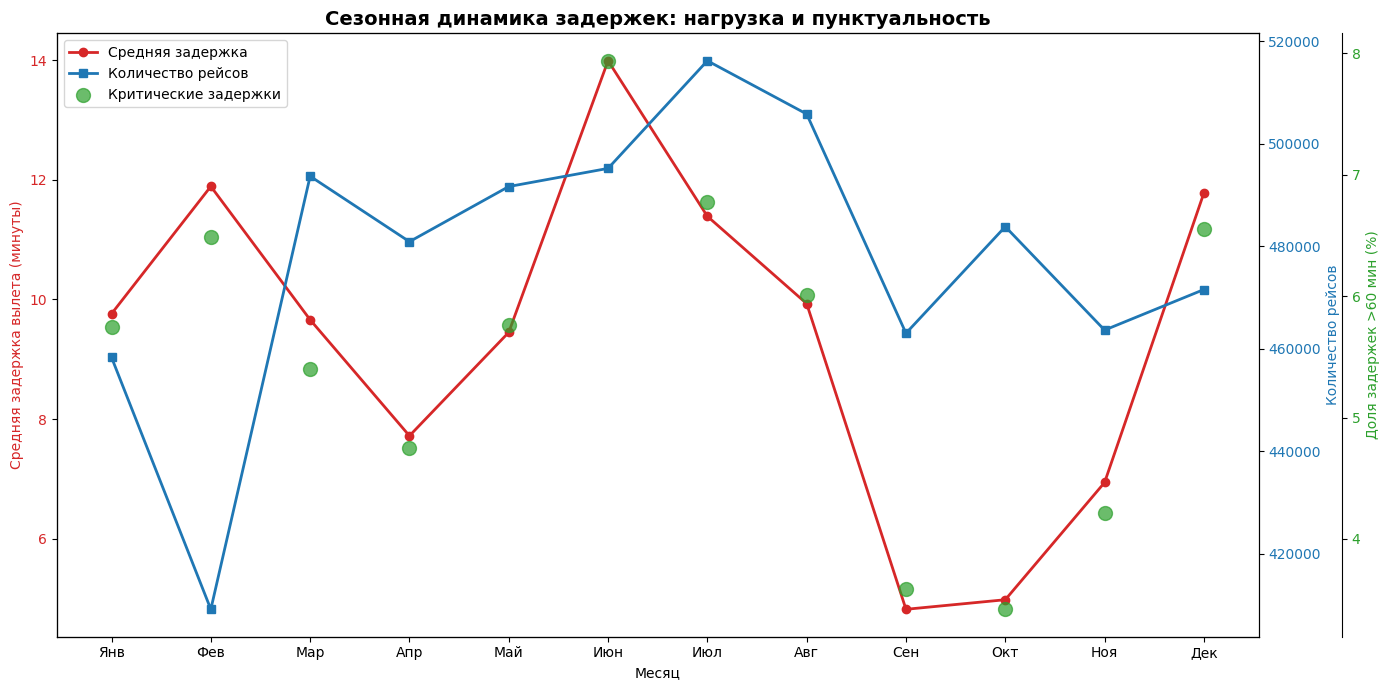

In [25]:
#Словарь для названий месяцев
months_map = {1: 'Янв', 2: 'Фев', 3: 'Мар', 4: 'Апр', 5: 'Май', 6: 'Июн',
              7: 'Июл', 8: 'Авг', 9: 'Сен', 10: 'Окт', 11: 'Ноя', 12: 'Дек'}

#Расчет метрик по месяцам
monthly_stats = flights.groupby('MONTH').agg(
    avg_delay=('DEPARTURE_DELAY', 'mean'),
    total_flights=('DEPARTURE_DELAY', 'count'),
    severe_delay_rate=('DEPARTURE_DELAY', lambda x: (x > 60).mean() * 100)
).round(2)

#Создание фигуры с двумя осями
fig, ax1 = plt.subplots(figsize=(14, 7))

#Линия средних задержек
color = 'tab:red'
ax1.set_xlabel('Месяц')
ax1.set_ylabel('Средняя задержка вылета (минуты)', color=color)
line1 = ax1.plot(monthly_stats.index, monthly_stats['avg_delay'], color=color, marker='o', linewidth=2, label='Средняя задержка')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([months_map[i] for i in range(1, 13)])

#Вторая ось для количества рейсов
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Количество рейсов', color=color)
line2 = ax2.plot(monthly_stats.index, monthly_stats['total_flights'], color=color, marker='s', linewidth=2, label='Количество рейсов')
ax2.tick_params(axis='y', labelcolor=color)

#Добавление третьей оси для доли критических задержек (используем scatter)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
color = 'tab:green'
ax3.set_ylabel('Доля задержек >60 мин (%)', color=color)
scatter = ax3.scatter(monthly_stats.index, monthly_stats['severe_delay_rate'], color=color, s=100, alpha=0.7, label='Критические задержки', zorder=5)
ax3.tick_params(axis='y', labelcolor=color)

plt.title('Сезонная динамика задержек: нагрузка и пунктуальность', fontsize=14, fontweight='bold')

#Объединение легенд
lines = line1 + line2 + [scatter]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()

#### Вывод
Видно, что пик задержек приходится на летние месяцы и декабрь, что совпадает с периодами максимальной нагрузки и неблагоприятных погодных условий. Также зимой доля критических задержек растет, скорее всего из-за погодных факторов (обледенение и т.д.).